# Loan Evaluation and Prediction Model

In [1]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_path = Path("../data/loan_approval_dataset.csv")
print(data_path)
print(data_path.exists())

..\data\loan_approval_dataset.csv
True


In [3]:
df = pd.read_csv(data_path)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.shape

(4269, 13)

In [5]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [8]:
df.describe(include='all')

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


### EDA

In [9]:
target_col = 'loan_status'

Using target column: loan_status


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

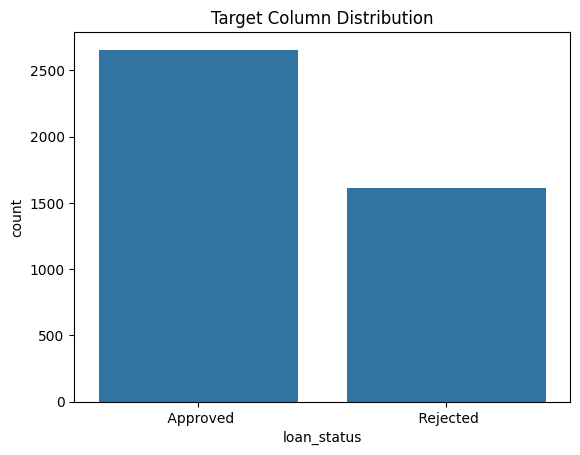

In [10]:
print("Using target column:", target_col)
display(df[target_col].value_counts(dropna=False))
sns.countplot(x=target_col, data=df)
plt.title("Target Column Distribution")
plt.show()

In [11]:
df = df.drop(columns = ["loan_id"], errors='ignore')
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [12]:
df_clf = df.dropna(subset=[target_col],).copy()

In [13]:
X = df_clf.drop(columns=[target_col])
y = df_clf[target_col].copy()

In [14]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [15]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

### Feature Types

In [16]:
import numpy as np

In [17]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [18]:
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['education', 'self_employed']
Numerical columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


### Preprocessing Pipeline

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [20]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])  

In [21]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

In [23]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 

## Stage 1 Classification Baseline

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [25]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [26]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

In [27]:
unique_vals = sorted(y.unique() )
unique_vals

[' Approved', ' Rejected']

In [28]:
y= df_clf[target_col].astype(str).str.strip().str.lower()
y.head

<bound method NDFrame.head of 0       approved
1       rejected
2       rejected
3       rejected
4       rejected
          ...   
4264    rejected
4265    approved
4266    rejected
4267    approved
4268    approved
Name: loan_status, Length: 4269, dtype: object>

In [29]:
y = (y == 'approved').astype(int)  # Convert to binary: 1 for approved, 0 for not approved

In [30]:
unique_vals = sorted(y.unique() )
unique_vals

[np.int64(0), np.int64(1)]

In [31]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)   

Training set size: (3415, 11)
Test set size: (854, 11)


### Fit Random Forest baseline pipelines

In [33]:
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier())
])

In [34]:
from sklearn.model_selection import GridSearchCV    

In [35]:
param_grid = {
    'rf_cls__n_estimators': [100, 200, 300, 400],
    'rf_cls__max_depth': [None, 4, 8, 10],
    'rf_cls__max_features': ['sqrt', None ]
}

grid = GridSearchCV(rf_clf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params (rf_cls) : ", grid.best_params_)
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_best))

Best params (rf_cls) :  {'rf_cls__max_depth': 10, 'rf_cls__max_features': None, 'rf_cls__n_estimators': 400}
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [36]:
# Random forest final baseline model
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier(n_estimators=400, max_depth=None, max_features=None,random_state=10, oob_score=True))
])

rf_clf_pipeline.fit(X_train, y_train)
y_pred_cls = rf_clf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_cls))
print("RF cls OOB score :", getattr(rf_clf_pipeline.named_steps['rf_cls'], 'oob_score_', None))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.98      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

RF cls OOB score : 0.9841874084919473


In [37]:
rf_clf_pipeline

,steps,"[('preprocessor', ...), ('rf_cls', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Checking Feature Importance

In [38]:
feature_importance = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_
feature_importance

array([4.38756169e-03, 2.18385601e-02, 3.59166892e-02, 7.99255753e-02,
       8.27558361e-01, 7.21379991e-03, 7.04073188e-03, 8.10355692e-03,
       5.60865741e-03, 4.55948976e-04, 3.95536327e-04, 8.27195445e-04,
       7.27825926e-04])

In [39]:
preprocessor = rf_clf_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__no_of_dependents', 'num__income_annum', 'num__loan_amount',
       'num__loan_term', 'num__cibil_score',
       'num__residential_assets_value', 'num__commercial_assets_value',
       'num__luxury_assets_value', 'num__bank_asset_value',
       'cat__education_ Graduate', 'cat__education_ Not Graduate',
       'cat__self_employed_ No', 'cat__self_employed_ Yes'], dtype=object)

Top 10 Important Features : 
                           Feature  Importance
4                num__cibil_score    0.827558
3                  num__loan_term    0.079926
2                num__loan_amount    0.035917
1               num__income_annum    0.021839
7        num__luxury_assets_value    0.008104
5   num__residential_assets_value    0.007214
6    num__commercial_assets_value    0.007041
8           num__bank_asset_value    0.005609
0           num__no_of_dependents    0.004388
11         cat__self_employed_ No    0.000827


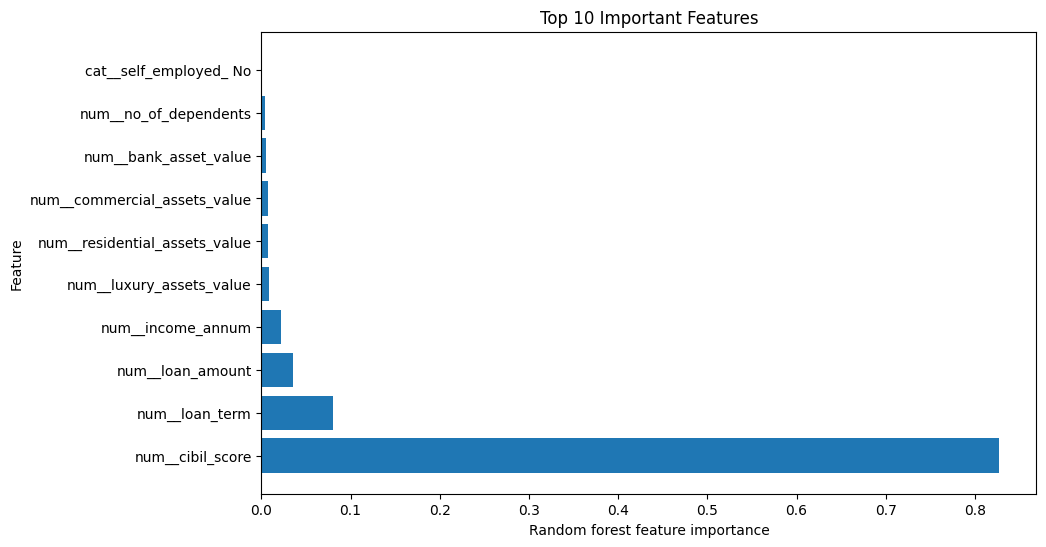

In [40]:
feature_importance = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_

preprocessor = rf_clf_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame(
    {
        'Feature' : feature_names,
        'Importance'  : feature_importance
    }
)

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Important Features : \n", importance_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel("Random forest feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.show()


# Stage 2: Regression

In [41]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [42]:
df['loan_status'] = df['loan_status'].str.strip()

In [43]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [44]:
approved_df = df[df['loan_status'] == 'Approved'].copy()

In [45]:
approved_df.shape

(2656, 12)

In [46]:
approved_df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
6,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
8,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
10,4,Graduate,Yes,2900000,11200000,2,547,8100000,4700000,9500000,3100000,Approved
13,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,Approved


In [47]:
reg_target = "loan_amount"
reg_df = approved_df.dropna(subset=[reg_target],).copy()

In [48]:
X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]

In [49]:
cat_cols_reg = X_reg.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.to_list()

In [50]:
print("Categorical columns : ", cat_cols_reg)
print("Numerical columns : ", num_cols_reg)

Categorical columns :  ['education', 'self_employed', 'loan_status']
Numerical columns :  ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [51]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=10)
print("Train size : ", Xr_train.shape)
print("Test size : ", Xr_test.shape)


Train size :  (2124, 11)
Test size :  (532, 11)


In [52]:
reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
], remainder='drop')

## Fit RF_reg baseline model

In [53]:
from sklearn.ensemble import RandomForestRegressor

In [54]:
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor())
])

In [55]:
param_reg_grid = {
    'rf_reg__n_estimators' : [100,200,300,400],
    'rf_reg__max_depth' : [None, 4, 8, 10],
    'rf_reg__max_features' : ['sqrt', None],
    'rf_reg__min_samples_split' : [2,5,10]
}

In [56]:
grid = GridSearchCV(rf_reg_pipeline, param_reg_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(Xr_train, yr_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'rf_reg__max_depth': [None, 4, ...], 'rf_reg__max_features': ['sqrt', None], 'rf_reg__min_samples_split': [2, 5, ...], 'rf_reg__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [57]:
print("Best params (rf_reg) : ", grid.best_params_)
best_reg = grid.best_estimator_

Best params (rf_reg) :  {'rf_reg__max_depth': 8, 'rf_reg__max_features': None, 'rf_reg__min_samples_split': 10, 'rf_reg__n_estimators': 300}


In [58]:
grid.best_score_

np.float64(0.8697389409175486)

### Regression Validation

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [60]:
# Best params (rf_reg) :  {'rf_reg__max_depth': 8, 'rf_reg__max_features': None, 'rf_reg__min_samples_split': 5, 'rf_reg__n_estimators': 200}


rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor(
        max_depth=8,
        max_features = None,
        min_samples_split = 5,
        n_estimators=200,
        random_state=10
    ))
])

rf_reg_pipeline.fit(Xr_train, yr_train)
yr_test_pred = rf_reg_pipeline.predict(Xr_test)
print("MSE : ",  mean_squared_error(yr_test, yr_test_pred))
print("MAE : ",  mean_absolute_error(yr_test, yr_test_pred))
print("R2 : ",  r2_score(yr_test, yr_test_pred))

MSE :  11195455918354.133
MAE :  2512447.573377621
R2 :  0.8643937813524751


## Feature Importance

Top 10 Important Features : 
                           Feature  Importance
1               num__income_annum    0.933516
3                num__cibil_score    0.014345
6        num__luxury_assets_value    0.011297
4   num__residential_assets_value    0.011170
5    num__commercial_assets_value    0.009901
7           num__bank_asset_value    0.008664
2                  num__loan_term    0.005687
0           num__no_of_dependents    0.003711
10         cat__self_employed_ No    0.000528
11        cat__self_employed_ Yes    0.000436


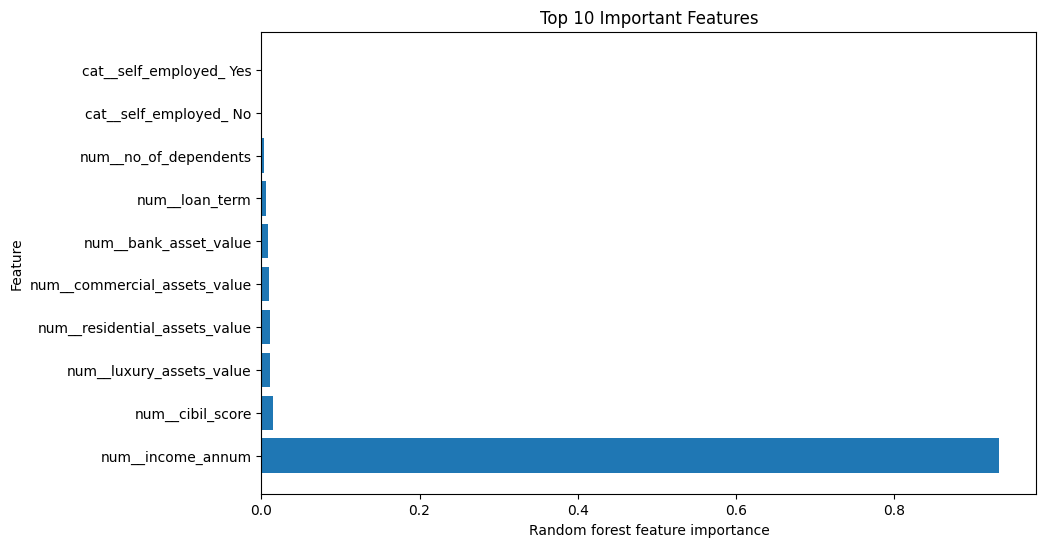

In [61]:
feature_importance = rf_reg_pipeline.named_steps['rf_reg'].feature_importances_

preprocessor = rf_reg_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame(
    {
        'Feature' : feature_names,
        'Importance'  : feature_importance
    }
)

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Important Features : \n", importance_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel("Random forest feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.show()


# Save Artifacts and combine them in a prediction function

In [62]:
import joblib

In [63]:
joblib.dump(rf_clf_pipeline, '../models/stage_1_rf_classifier_pipeline.pkl')
joblib.dump(rf_reg_pipeline, '../models/stage_2_rf_regression_pipeline.pkl')

['../models/stage_2_rf_regression_pipeline.pkl']

## Prediction Function

In [64]:
clf = joblib.load("../models/stage_1_rf_classifier_pipeline.pkl")
reg = joblib.load("../models/stage_2_rf_regression_pipeline.pkl")

In [65]:
# 100 columns
# 10 columns
def two_stage_predict(applicant_df):
    out = {}

    # stage 1
    approve = clf.predict(applicant_df)[0]
    # print(approve)
    out['loan_status'] = int(approve)

    if approve == 1:
        # stage 2
        applicant_df['loan_status'] = 'Approve'
        loan_amount_pred = reg.predict(applicant_df)[0]
        out['regression_prediction'] = float(loan_amount_pred)
    else:
        print("Not Approved")
    
    return out

In [66]:
example_row = X_test.iloc[[0]]
print("Example row : \n")
display(example_row)

Example row : 



,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3933,0,Not Graduate,No,9800000,20100000,16,606,6200000,800000,37300000,8700000


In [67]:
example_row.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 3933 to 3933
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          1 non-null      int64 
 1   education                 1 non-null      object
 2   self_employed             1 non-null      object
 3   income_annum              1 non-null      int64 
 4   loan_amount               1 non-null      int64 
 5   loan_term                 1 non-null      int64 
 6   cibil_score               1 non-null      int64 
 7   residential_assets_value  1 non-null      int64 
 8   commercial_assets_value   1 non-null      int64 
 9   luxury_assets_value       1 non-null      int64 
 10  bank_asset_value          1 non-null      int64 
dtypes: int64(9), object(2)
memory usage: 96.0+ bytes


In [68]:
print(reg.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum' 'loan_term'
 'cibil_score' 'residential_assets_value' 'commercial_assets_value'
 'luxury_assets_value' 'bank_asset_value' 'loan_status']


In [69]:
print(clf.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum'
 'loan_amount' 'loan_term' 'cibil_score' 'residential_assets_value'
 'commercial_assets_value' 'luxury_assets_value' 'bank_asset_value']


In [70]:
two_stage_predict(example_row)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5932\470034258.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  applicant_df['loan_status'] = 'Approve'


{'loan_status': 1, 'regression_prediction': 24661890.99107742}

In [71]:
sample = pd.DataFrame([{
    'no_of_dependents' : 1,
    'education' : 'Graduate',
    'self_employed' : 'No', 
    'income_annum' : 1200000,
    'loan_amount' : 30000,
    'loan_term' : 12, 
    'cibil_score' : 800, 
    'residential_assets_value' : 2000000,
    'commercial_assets_value' : 2000000, 
    'luxury_assets_value' : 0, 
    'bank_asset_value' : 55000
}])

In [72]:
sample

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,Graduate,No,1200000,30000,12,800,2000000,2000000,0,55000


In [73]:
two_stage_predict(sample)

{'loan_status': 1, 'regression_prediction': 3052769.1915370994}

In [74]:
approval_output = clf.predict(sample)
approval_output

array([1])

In [75]:
approval_proba = clf.predict_proba(sample)
approval_proba

array([[0.1825, 0.8175]])

In [76]:
approval_proba.shape

(1, 2)

In [77]:
approval_proba[0]

array([0.1825, 0.8175])

In [78]:
approval_proba[0][1]

np.float64(0.8175)

In [79]:
float(approval_proba[0, 1])

0.8175